<a href="https://colab.research.google.com/github/21anonymous/Advance-nuclear-physics-lab-/blob/main/Deconvolation_for_ba_and_co_with_and_without_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ba_without.txt_output.txt generated successfully
1.2Ba_with.txt_output.txt generated successfully


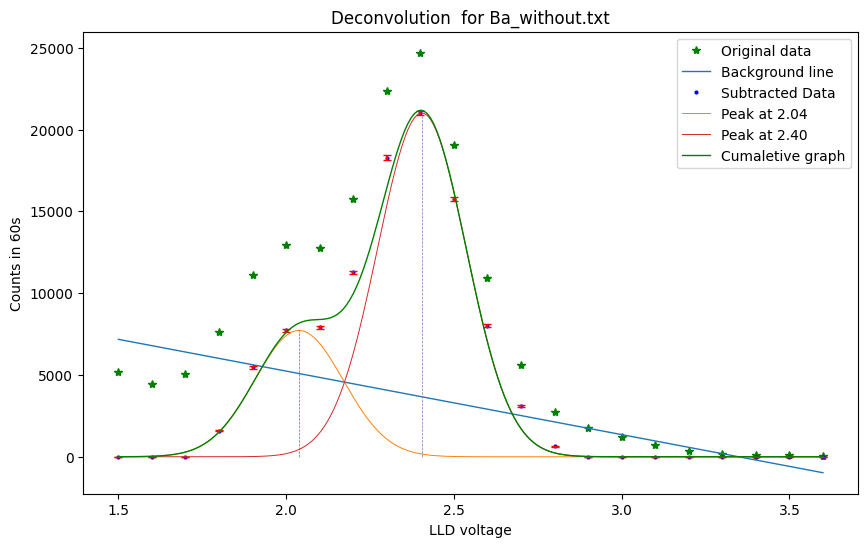

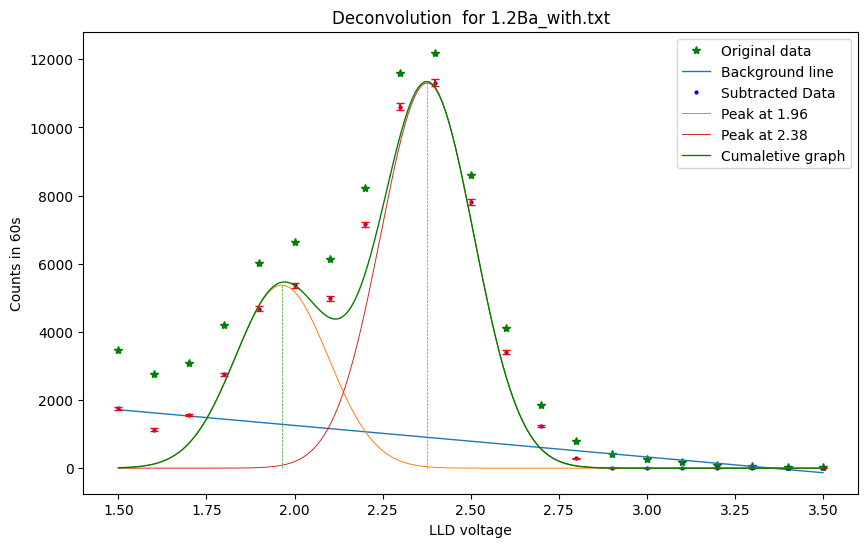

In [ ]:
#for ba
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import find_peaks
import math
from datetime import datetime
from IPython import get_ipython
from IPython.display import display
# Define Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma**2))

# Function to sum multiple Gaussians
def total_gaussian(x, amplitudes, means, sigmas):
    return sum(gaussian(x, a, m, s) for a, m, s in zip(amplitudes, means, sigmas))

# Chi-square function to minimize
def chi_square(params, x, y, y_err):
    amplitudes = params[:len(means)]
    fitted_means = params[len(means):2*len(means)]
    fitted_sigmas = params[2*len(means):]
    model = total_gaussian(x, amplitudes, fitted_means, fitted_sigmas)
    return np.sum(((y - model) / y_err) ** 2) / (len(y) - len(params))


# Function to read data from a file
def read_data(file):
    x_data, y_data = [], []
    try:
        with open(file, "r") as f:
            for line in f:
                if line.strip():
                    columns = line.split()
                    if len(columns) >= 2:
                        x_data.append(float(columns[0]))
                        y_data.append(float(columns[1]))
                    else:
                        print(f"Warning: Skipping line (not enough data): {line.strip()}")
    except FileNotFoundError:
        print(f"Error: The file {file} was not found.")
        return np.array([]), np.array([])

    return np.array(x_data), np.array(y_data)
def line_fit(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    intercept = y_mean - slope * x_mean
    return slope, intercept
# Read data from the file
#first name should be source and at least have four word in file name seperated by _
files=["Ba_without.txt","1.2Ba_with.txt"]
solid_angles=np.array([2.11,0.72])
means = [2,2.4]  # Example values
sigmas = [ 0.12,0.12]
decay_fraction=[0.62,0.62]
distances=[12.0,2.4]#in mm
#Enter manufacture date or T0
start_date = datetime(2015, 4, 1)#(YYYY, MM, DD)
current_date = datetime.today()
days_difference = (current_date - start_date).days
years_diff = days_difference / 365.25

a0=138*(10**3)#Initial activity in Bq
t_half=10.5# Half life of source in years
decay_frac=[0.99,0.99]
at=a0*np.exp(-(0.693*years_diff)/t_half)

for file,solid_angle,distance in zip(files,solid_angles,distances):
    # print(f"For the {file.split('')[0]} {file.split('')[2]} {file.split('_')[3]}\n")
    x_data, y_data_1= read_data(file)
    y_err = np.sqrt(y_data_1)  # error bars sqrt(N)
    output=f"{file.split(' ')[0]}_output.txt"
    #just a trick find background line
       # Find peaks for background line calculation
    #The variable y_data is not defined before this line causing error. It's defined later in line 100. Replacing with y_data_1
    peaks_new, _ = find_peaks(y_data_1, prominence=10, wlen=10) # prominence=max(y_bg)*0.1,  The varible y_bg is not defined causing the error. It will be defined in the for loop following this line. Replacing with arbitary value 10 for now.

    # Define peak regions and find minimum points
    x_bg, y_bg = [], []
    window_size = 10  # Adjust as needed
    for peak_index in peaks_new:
        region_start = max(0, peak_index - window_size)
        region_end = min(len(y_data_1), peak_index + window_size) #Replacing y_data with y_data_1 as it's not yet defined.
        min_index = np.argmin(y_data_1[region_start:region_end]) #Replacing y_data with y_data_1 as it's not yet defined.
        x_bg.append(x_data[region_start + min_index])
        y_bg.append(y_data_1[region_start + min_index]) #Replacing y_data with y_data_1 as it's not yet defined.

    # Fit background line using minimum points
    slope, intercept = line_fit(x_bg, y_bg)
    y_background = slope * x_data + intercept

    #note make the point slight above where you want to fit background line
  # """  y_bg=np.abs(y_data_1 - max(y_data_1)) # This line and below lines were commented out. Removing the comment to ensure proper indentation
  #   peaks, _ = find_peaks(y_bg, prominence=10)
  #   x1=[x_data[peaks[0]],x_data[peaks[-1]]]
  #   y1=[y_data_1[peaks[0]],y_data_1[peaks[-1]]]
  #   slope,intercept=line_fit(x1, y1)"""
    y_data=np.maximum(y_data_1-abs(y_background),1e-5)
    # peaks_new, _ = find_peaks(y_data, prominence=max(y_bg)*0.1,wlen=10)
    plt.figure(figsize=(10, 6))
    plt.plot(x_data,y_data_1,"g*" ,label='Original data', linewidth=1)
    plt.plot(x_data,y_background ,label='Background line', linewidth=1)
    p=[np.argmin(abs(x_data-m))for m in means]
    peaks_new=y_data[p]
    #Parameter bounding
    mean_bounds = [(m - m*0.05, m + m*0.05) for m in means] # 5% around mean and sigma
    sigma_bounds = [(s - s*0.10, s + s*0.10) for s in sigmas]
    amplitude_bounds = [(0, pv) for pv in peaks_new]
    initial_guess = np.concatenate([np.full(len(means), max(y_data)), means, sigmas])
    bound = amplitude_bounds + mean_bounds + sigma_bounds
    # Optimize amplitudes
    result = minimize(chi_square, initial_guess, args=(x_data, y_data, y_err), method='L-BFGS-B', bounds=bound)
    optimized_amplitudes = result.x[:len(means)]
    optimized_means = result.x[len(means):2*len(means)]
    optimized_sigmas = result.x[2*len(means):]

    # Plot results
    y_bar=np.sqrt(y_data)
    # plt.scatter(x_data, y_data, label='Subtracted Data', linewidth=0.5,color='black')
    plt.plot(x_data, y_data, "bo", label='Subtracted Data',markersize=2)
    plt.errorbar(x_data, y_data, yerr=y_bar, fmt="o", color="red", markersize=0.1, capsize=3)
    y_smooth=np.zeros(len(x_data)*10)
    x_smooth=np.linspace(min(x_data),max(x_data),len(x_data)*10)
    with open(output, 'w') as out_file:
      out_file.write(f"{file}\n")
      out_file.write(f"\nHalf life of source= {t_half:.2f} years\n")
      out_file.write(f"Start Date: {start_date}\n")
      out_file.write(f"Current Date: {current_date}\n")
      out_file.write(f"Initial activity of the source= {a0:.2f} Bq\n")
      out_file.write(f"Time difference(t0-t) = {years_diff:.2f} years\n")
      out_file.write(f"Current Activity of the source= {at:.2f} Bq\n\n")
      for a, m, s ,df in zip(optimized_amplitudes, optimized_means,optimized_sigmas,decay_fraction):
          y_new= gaussian(x_data, a, m, s)
          plt.plot(x_smooth, gaussian(x_smooth, a, m, s),linewidth=0.7, label=f'Peak at {m:.2f}')
          y_smooth=y_smooth+gaussian(x_smooth, a, m, s)
          area=np.sum(gaussian(x_data, a, m, s))
          abs_eff=area/(60*at*df)
          intrinsic_eff=abs_eff*((4*math.pi)/(solid_angle))
          out_file.write(f"\nArea under the Peak ={m:.2f} is = {area/60:.0f} per second\n")
          out_file.write(f"Decay fraction is ={df}\n")
          out_file.write(f"Solid angle is ={solid_angle} in sr\n")
          out_file.write(f"No of particle emitted by  the source= {at*df:.0f} per second\n")
          out_file.write(f"Absolute efficiency is = {abs_eff*100:.4f} %\n")
          delta_abs_eff=abs_eff*100*np.sqrt((1/(area/60)*2)+(1/(at*df)*2))
          out_file.write(f"Error in Absolute efficiency is = {delta_abs_eff:.4f} %\n")
          out_file.write(f"No of particle incident on detector= {(at*df*solid_angle)/(math.pi*60):.2f} per second\n")
          out_file.write(f"Intrinsic efficiency is = {intrinsic_eff*100:.4f} %\n")
          delta_int_eff= intrinsic_eff*100*np.sqrt(((delta_abs_eff)/(abs_eff*100))*2 + (0.001/distance)*2 + ((distance*0.001)/(distance*distance + 12.7*12.7))*2 + ((0.001*12.7)/(distance*distance + 12.7*12.7))*2 )
          out_file.write(f"Error in Intrinsic efficiency is = {delta_int_eff:.4f} %\n\n")
          out_file.write("#Voltage;Count;Background;subtracted data;fitted peak\n")
          for i in range(0, len(x_data),1):
             out_file.write(f"{x_data[i]:.1f};{y_data_1 [i]:.0f};{y_background[i]:.0f};{y_data[i]:.0f};{y_new[i]:.0f}\n")
          plt.plot([m,m],[0,a], linestyle='--', linewidth=0.5)
    plt.plot(x_smooth,y_smooth, label='Cumaletive graph', color='green', linewidth=1)
    plt.xlabel('LLD voltage')
    plt.ylabel('Counts in 60s')
    plt.title(f'Deconvolution  for {file}')
    plt.legend()
    plt.savefig(f"Ba_solid_angle{solid_angle}.png", format='png', dpi=300,transparent=False)
    print(f"{output} generated successfully")
plt.show()

Co_without.txt_output.txt generated successfully
1.2Co_with.txt_output.txt generated successfully


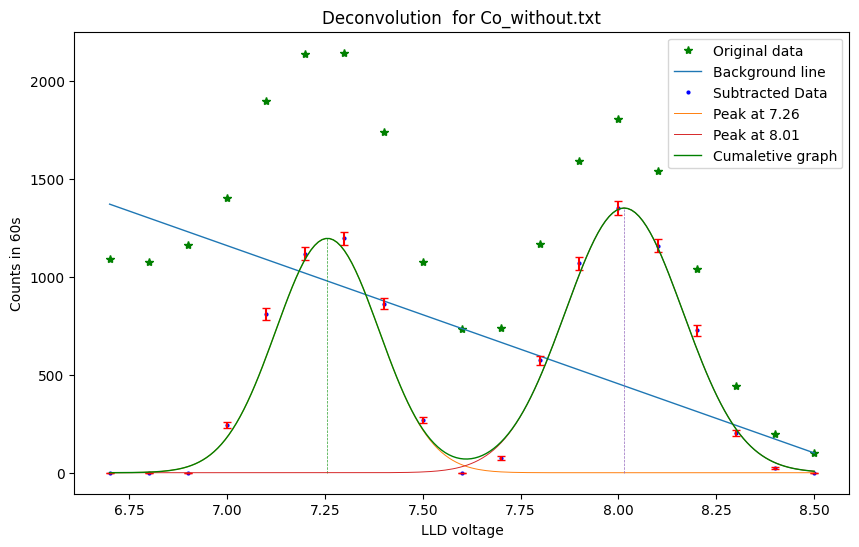

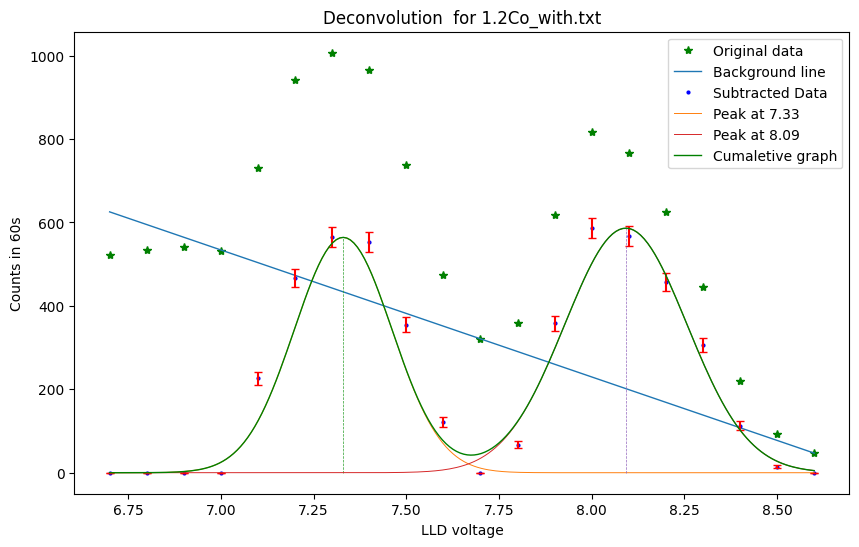

In [ ]:
# for co
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import find_peaks
import math
from datetime import datetime
from IPython import get_ipython
from IPython.display import display
# Define Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma**2))

# Function to sum multiple Gaussians
def total_gaussian(x, amplitudes, means, sigmas):
    return sum(gaussian(x, a, m, s) for a, m, s in zip(amplitudes, means, sigmas))

# Chi-square function to minimize
def chi_square(params, x, y, y_err):
    amplitudes = params[:len(means)]
    fitted_means = params[len(means):2*len(means)]
    fitted_sigmas = params[2*len(means):]
    model = total_gaussian(x, amplitudes, fitted_means, fitted_sigmas)
    return np.sum(((y - model) / y_err) ** 2) / (len(y) - len(params))


# Function to read data from a file
def read_data(file):
    x_data, y_data = [], []
    try:
        with open(file, "r") as f:
            for line in f:
                if line.strip():
                    columns = line.split()
                    if len(columns) >= 2:
                        x_data.append(float(columns[0]))
                        y_data.append(float(columns[1]))
                    else:
                        print(f"Warning: Skipping line (not enough data): {line.strip()}")
    except FileNotFoundError:
        print(f"Error: The file {file} was not found.")
        return np.array([]), np.array([])

    return np.array(x_data), np.array(y_data)
def line_fit(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    intercept = y_mean - slope * x_mean
    return slope, intercept
# Read data from the file
#first name should be source and at least have four word in file name seperated by _
files=["Co_without.txt","1.2Co_with.txt"]
solid_angles=np.array([2.11,0.72])
means = [7.3,8]  # Example values
sigmas = [ 0.12,0.15]
decay_fraction=[1,1]
distances=[12.0,2.4]#in mm
#Enter manufacture date or T0
start_date = datetime(2008, 4, 1)#(YYYY, MM, DD)
current_date = datetime.today()
days_difference = (current_date - start_date).days
years_diff = days_difference / 365.25

a0=16.65*(10**4)#Initial activity in Bq
t_half=5.27# Half life of source in years
decay_frac=[0.99,0.99]
at=a0*np.exp(-(0.693*years_diff)/t_half)

for file,solid_angle,distance in zip(files,solid_angles,distances):
    # print(f"For the {file.split('')[0]} {file.split('')[2]} {file.split('_')[3]}\n")
    x_data, y_data_1= read_data(file)
    # Check if x_data is empty
    if x_data.size == 0:
        print(f"Error: No data found in file '{file}'. Skipping this file.")
        continue  # Skip to the next file
    y_err = np.sqrt(y_data_1)  # error bars sqrt(N)
    output=f"{file.split(' ')[0]}_output.txt"
    #just a trick find background line
       # Find peaks for background line calculation
    #The variable y_data is not defined before this line causing error. It's defined later in line 100. Replacing with y_data_1
    peaks_new, _ = find_peaks(y_data_1, prominence=10, wlen=10) # prominence=max(y_bg)*0.1,  The varible y_bg is not defined causing the error. It will be defined in the for loop following this line. Replacing with arbitary value 10 for now.

    # Define peak regions and find minimum points
    x_bg, y_bg = [], []
    window_size = 10  # Adjust as needed
    for peak_index in peaks_new:
        region_start = max(0, peak_index - window_size)
        region_end = min(len(y_data_1), peak_index + window_size) #Replacing y_data with y_data_1 as it's not yet defined.
        min_index = np.argmin(y_data_1[region_start:region_end]) #Replacing y_data with y_data_1 as it's not yet defined.
        x_bg.append(x_data[region_start + min_index])
        y_bg.append(y_data_1[region_start + min_index]) #Replacing y_data with y_data_1 as it's not yet defined.

    # Fit background line using minimum points
    slope, intercept = line_fit(x_bg, y_bg)
    y_background = slope * x_data + intercept

    #note make the point slight above where you want to fit background line
  # """  y_bg=np.abs(y_data_1 - max(y_data_1)) # This line and below lines were commented out. Removing the comment to ensure proper indentation
  #   peaks, _ = find_peaks(y_bg, prominence=10)
  #   x1=[x_data[peaks[0]],x_data[peaks[-1]]]
  #   y1=[y_data_1[peaks[0]],y_data_1[peaks[-1]]]
  #   slope,intercept=line_fit(x1, y1)"""
    y_data=np.maximum(y_data_1-abs(y_background),1e-5)
    # peaks_new, _ = find_peaks(y_data, prominence=max(y_bg)*0.1,wlen=10)
    plt.figure(figsize=(10, 6))
    plt.plot(x_data,y_data_1,"g*" ,label='Original data', linewidth=1)
    plt.plot(x_data,y_background ,label='Background line', linewidth=1)
    p=[np.argmin(abs(x_data-m))for m in means]
    peaks_new=y_data[p]
    #Parameter bounding
    mean_bounds = [(m - m*0.05, m + m*0.05) for m in means] # 5% around mean and sigma
    sigma_bounds = [(s - s*0.10, s + s*0.10) for s in sigmas]
    amplitude_bounds = [(0, pv) for pv in peaks_new]
    initial_guess = np.concatenate([np.full(len(means), max(y_data)), means, sigmas])
    bound = amplitude_bounds + mean_bounds + sigma_bounds
    # Optimize amplitudes
    result = minimize(chi_square, initial_guess, args=(x_data, y_data, y_err), method='L-BFGS-B', bounds=bound)
    optimized_amplitudes = result.x[:len(means)]
    optimized_means = result.x[len(means):2*len(means)]
    optimized_sigmas = result.x[2*len(means):]

    # Plot results
    y_bar=np.sqrt(y_data)
    # plt.scatter(x_data, y_data, label='Subtracted Data', linewidth=0.5,color='black')
    plt.plot(x_data, y_data, "bo", label='Subtracted Data',markersize=2)
    plt.errorbar(x_data, y_data, yerr=y_bar, fmt="o", color="red", markersize=0.1, capsize=3)
    y_smooth=np.zeros(len(x_data)*10)
    x_smooth=np.linspace(min(x_data),max(x_data),len(x_data)*10)
    with open(output, 'w') as out_file:
      out_file.write(f"{file}\n")
      out_file.write(f"\nHalf life of source= {t_half:.2f} years\n")
      out_file.write(f"Start Date: {start_date}\n")
      out_file.write(f"Current Date: {current_date}\n")
      out_file.write(f"Initial activity of the source= {a0:.2f} Bq\n")
      out_file.write(f"Time difference(t0-t) = {years_diff:.2f} years\n")
      out_file.write(f"Current Activity of the source= {at:.2f} Bq\n\n")
      for a, m, s ,df in zip(optimized_amplitudes, optimized_means,optimized_sigmas,decay_fraction):
          y_new= gaussian(x_data, a, m, s)
          plt.plot(x_smooth, gaussian(x_smooth, a, m, s),linewidth=0.7, label=f'Peak at {m:.2f}')
          y_smooth=y_smooth+gaussian(x_smooth, a, m, s)
          area=np.sum(gaussian(x_data, a, m, s))
          abs_eff=area/(60*at*df)
          intrinsic_eff=abs_eff*((4*math.pi)/(solid_angle))
          out_file.write(f"\nArea under the Peak ={m:.2f} is = {area/60:.0f} per second\n")
          out_file.write(f"Decay fraction is ={df}\n")
          out_file.write(f"Solid angle is ={solid_angle} in sr\n")
          out_file.write(f"No of particle emitted by  the source= {at*df:.0f} per second\n")
          out_file.write(f"Absolute efficiency is = {abs_eff*100:.4f} %\n")
          delta_abs_eff=abs_eff*100*np.sqrt((1/(area/60)*2)+(1/(at*df)*2))
          out_file.write(f"Error in Absolute efficiency is = {delta_abs_eff:.4f} %\n")
          out_file.write(f"No of particle incident on detector= {(at*df*solid_angle)/(math.pi*60):.2f} per second\n")
          out_file.write(f"Intrinsic efficiency is = {intrinsic_eff*100:.4f} %\n")
          delta_int_eff= intrinsic_eff*100*np.sqrt(((delta_abs_eff)/(abs_eff*100))*2 + (0.001/distance)*2 + ((distance*0.001)/(distance*distance + 12.7*12.7))*2 + ((0.001*12.7)/(distance*distance + 12.7*12.7))*2 )
          out_file.write(f"Error in Intrinsic efficiency is = {delta_int_eff:.4f} %\n\n")
          out_file.write("#Voltage;Count;Background;subtracted data;fitted peak\n")
          for i in range(0, len(x_data),1):
             out_file.write(f"{x_data[i]:.1f};{y_data_1 [i]:.0f};{y_background[i]:.0f};{y_data[i]:.0f};{y_new[i]:.0f}\n")
          plt.plot([m,m],[0,a], linestyle='--', linewidth=0.5)
    plt.plot(x_smooth,y_smooth, label='Cumaletive graph', color='green', linewidth=1)
    plt.xlabel('LLD voltage')
    plt.ylabel('Counts in 60s')
    plt.title(f'Deconvolution  for {file}')
    plt.legend()
    plt.savefig(f"Co_solid_angle{solid_angle}.png", format='png', dpi=300,transparent=False)
    print(f"{output} generated successfully")
plt.show()